In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

In [3]:
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

Số dòng: 7043
Số cột: 21


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [13]:
missing = df.isnull().sum()

missing[missing > 0]

TotalCharges    11
dtype: int64

In [11]:
print("Số ô trống trong TotalCharges:",
      (df["TotalCharges"].str.strip() == "").sum())

Số ô trống trong TotalCharges: 11


In [12]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Kiểu dữ liệu TotalCharges:", df["TotalCharges"].dtype)
print("Số giá trị thiếu:", df["TotalCharges"].isnull().sum())

Kiểu dữ liệu TotalCharges: float64
Số giá trị thiếu: 11


In [16]:
print("Số dòng trùng:", df.duplicated().sum())

Số dòng trùng: 0


In [17]:
print("Số customerID:", df["customerID"].nunique())
print("Số dòng:", len(df))

Số customerID: 7043
Số dòng: 7043


In [18]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [19]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


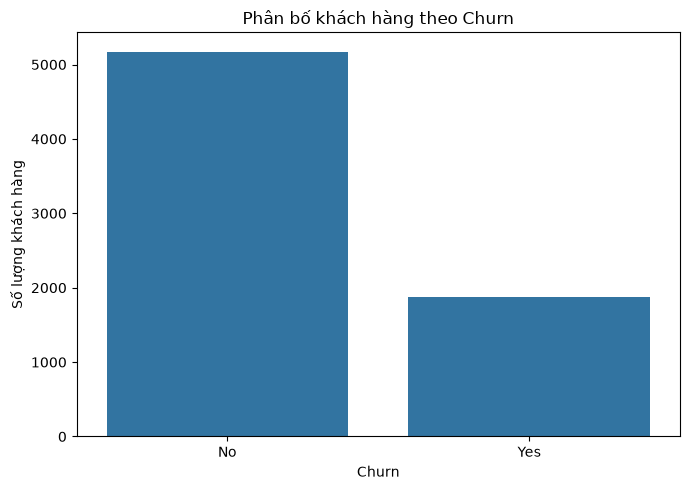

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Phân bố khách hàng theo Churn")
plt.xlabel("Churn")
plt.ylabel("Số lượng khách hàng")

plt.tight_layout()

plt.savefig(
    "../reports/figures/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


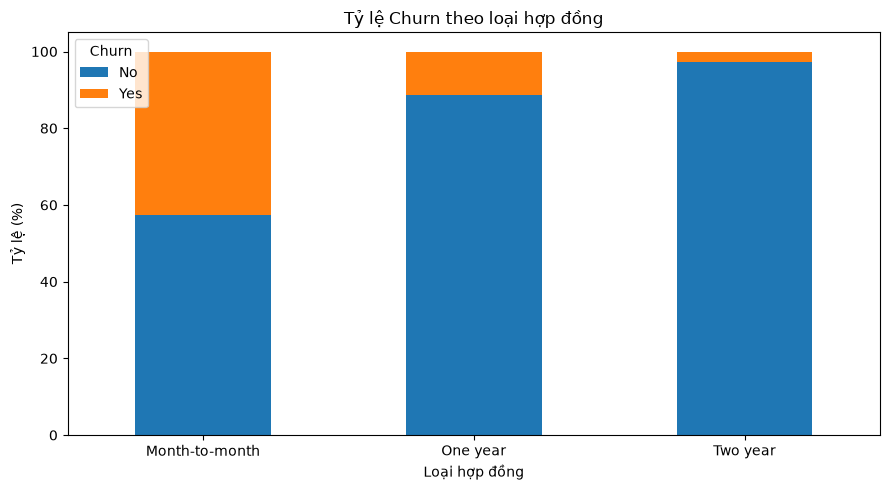

In [22]:
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Tỷ lệ Churn theo loại hợp đồng")
plt.xlabel("Loại hợp đồng")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.tight_layout()

plt.savefig(
    "../reports/figures/churn_by_contract.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


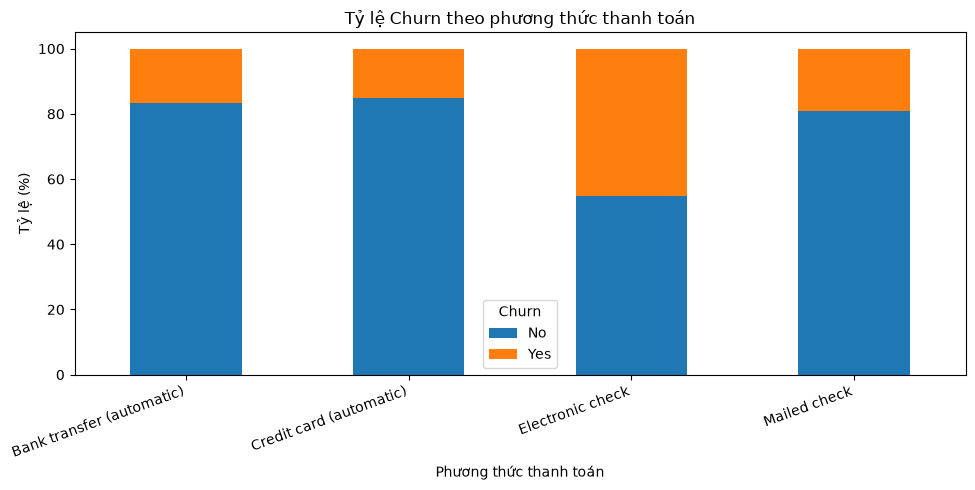

In [24]:
payment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Tỷ lệ Churn theo phương thức thanh toán")
plt.xlabel("Phương thức thanh toán")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Churn")

plt.tight_layout()

plt.savefig(
    "../reports/figures/churn_by_payment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

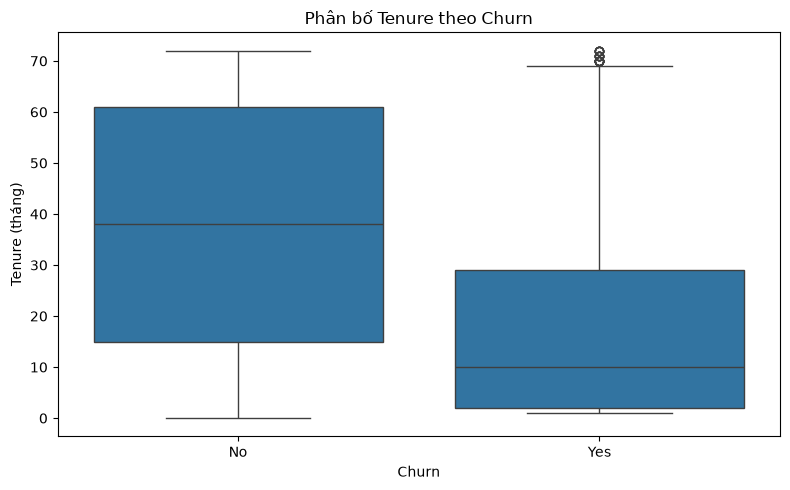

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Phân bố Tenure theo Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (tháng)")

plt.tight_layout()

plt.savefig(
    "../reports/figures/tenure_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

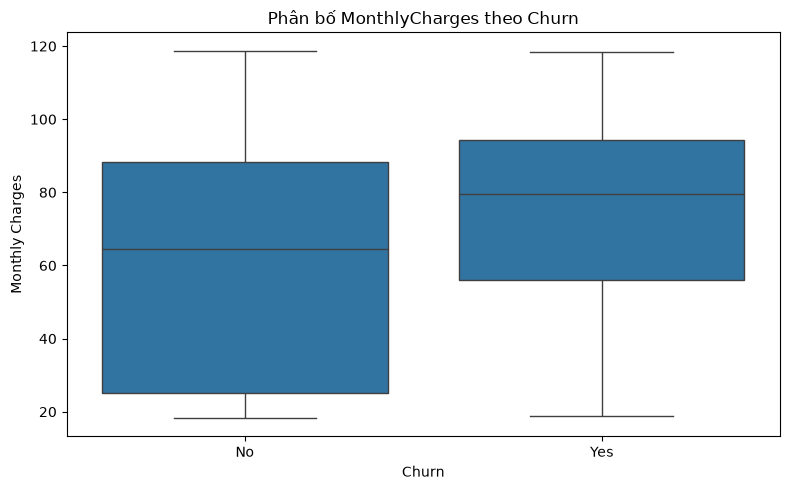

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Phân bố MonthlyCharges theo Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()

plt.savefig(
    "../reports/figures/monthly_charges_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
numeric_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [31]:
df["Churn_num"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

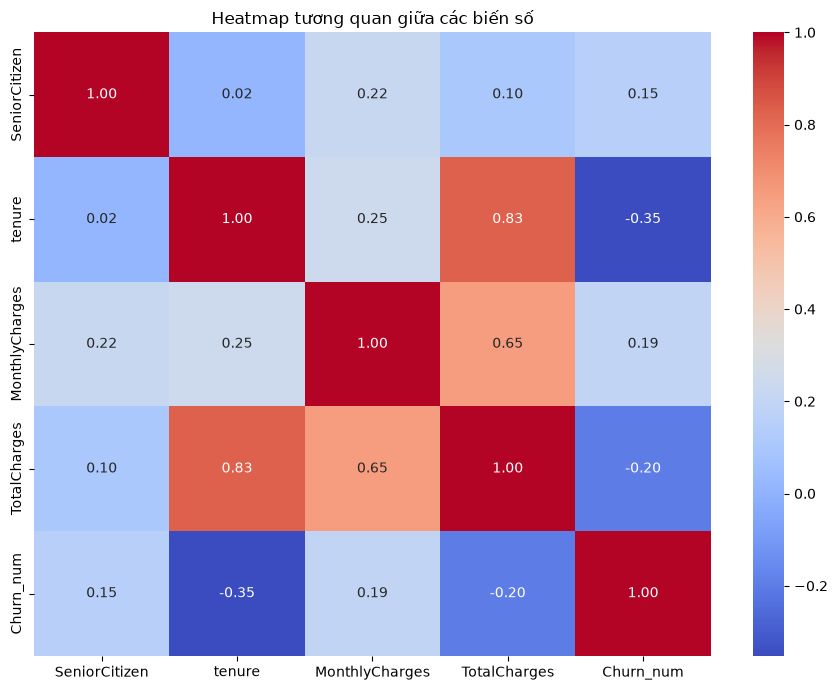

In [32]:
heatmap_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_num"
]

corr = df[heatmap_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Heatmap tương quan giữa các biến số")

plt.tight_layout()

plt.savefig(
    "../reports/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()